# EDA

### Libraries and constants

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from utils import (
    auto_iqr_winsorization_limits,
    breusch_pagan_test,
    calculate_feature_psi,
    check_stationarity,
    detect_features_to_restore_full_rank,
    detect_perfect_multicollinearity_via_rank,
    get_cooks_distances,
    get_null_info,
    get_vif_features_to_drop,
    perform_advanced_vif_analysis,
    plot_features_against_target,
    render_correlations,
    target_info,
    white_test,
)


In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42
TARGET_NAME = 'state'

### Data import

In [3]:
def obtain_time_domain_features(df: pd.DataFrame) -> dict:
    """Extracts time domain features from the 3D accelerometer signal."""
    data_window = {}
    axes = ['accelerometer_X', 'accelerometer_Y', 'accelerometer_Z']
    short_names = {'accelerometer_X': 'X', 'accelerometer_Y': 'Y', 'accelerometer_Z': 'Z'}

    for axis in axes:
        values = df[axis].to_numpy()
        name = short_names[axis]

        mean_val = np.mean(values)
        max_val = np.max(values)
        min_val = np.min(values)

        data_window[f'mean_{name}'] = mean_val
        data_window[f'var_{name}'] = np.var(values)
        data_window[f'std_{name}'] = np.std(values)
        data_window[f'median_{name}'] = np.median(values)
        data_window[f'max_{name}'] = max_val
        data_window[f'min_{name}'] = min_val
        data_window[f'range_{name}'] = max_val - min_val
        data_window[f'rms_{name}'] = np.sqrt(np.mean(values**2))
        data_window[f'skew_{name}'] = stats.skew(values)
        data_window[f'kurt_{name}'] = stats.kurtosis(values)
        data_window[f'iqr_{name}'] = stats.iqr(values)
        data_window[f'mad_{name}'] = np.mean(np.abs(values - mean_val))
        data_window[f'power_{name}'] = np.mean(values**2)
        data_window[f'energy_{name}'] = np.sum(values**2)

        counts, _ = np.histogram(values, bins=10)
        probs = counts / len(values)
        probs = probs[probs > 0]
        data_window[f'entropy_{name}'] = -np.sum(probs * np.log2(probs))

        data_window[f'idx_max_{name}'] = np.argmax(values)
        data_window[f'idx_min_{name}'] = np.argmin(values)

    x_vals = df['accelerometer_X'].to_numpy()
    y_vals = df['accelerometer_Y'].to_numpy()
    z_vals = df['accelerometer_Z'].to_numpy()

    data_window['sma'] = np.mean(np.abs(x_vals) + np.abs(y_vals) + np.abs(z_vals))
    data_window['corr_XY'] = np.corrcoef(x_vals, y_vals)[0, 1]
    data_window['corr_XZ'] = np.corrcoef(x_vals, z_vals)[0, 1]
    data_window['corr_YZ'] = np.corrcoef(y_vals, z_vals)[0, 1]

    return data_window


def obtain_frequency_domain_features(df: pd.DataFrame) -> dict:
    """Extracts frequency domain features (FFT) from the signal."""
    data_window = {}
    axes = ['accelerometer_X', 'accelerometer_Y', 'accelerometer_Z']
    short_names = {'accelerometer_X': 'X', 'accelerometer_Y': 'Y', 'accelerometer_Z': 'Z'}

    for axis in axes:
        values = df[axis].to_numpy()
        name = short_names[axis]
        n = len(values)

        fft_coeffs = np.fft.rfft(values)
        fft_mag = np.abs(fft_coeffs)
        fft_sq = fft_mag ** 2

        data_window[f'fft_band_power_{name}'] = np.sum(fft_sq) / n
        data_window[f'fft_energy_{name}'] = np.sum(fft_sq)
        data_window[f'fft_dc_{name}'] = fft_mag[0] # Zero-frequency bin (DC)
        data_window[f'fft_magnitude_{name}'] = np.mean(fft_mag[1:]) # Mean of rest
        data_window[f'fft_max_{name}'] = np.max(fft_mag)
        data_window[f'fft_min_{name}'] = np.min(fft_mag)

    return data_window

In [4]:
import re
from pathlib import Path
import pandas as pd

df_data = []

for cl in ['idle', 'running', 'stairs', 'walking']:
    path = Path('data') / cl

    if not path.exists():
        print(f"Warning: Path {path} does not exist. Skipping.")
        continue

    # 1. Safely find and collect ONLY valid files with their sequence numbers
    valid_files = []
    for f in path.iterdir():
        # Make sure it's a file and ends with .csv (ignores hidden folders/files)
        if f.is_file() and f.suffix.lower() == '.csv':
            # Extract the digit sequence from the filename
            match = re.search(r'\d+', f.stem)
            if match:
                file_number = int(match.group())
                valid_files.append((file_number, f))
            else:
                print(f"Skipping file (no number found): {f.name}")

    # 2. Sort the files numerically by that extracted number
    valid_files.sort(key=lambda x: x[0])

    # Extract just the sorted Path objects
    sorted_files = [item[1] for item in valid_files]

    # 3. Process the safely sorted files
    for f in sorted_files:
        # Read the file
        csv = pd.read_csv(f)

        # Normalize the data BEFORE feature extraction
        for axis in ['accelerometer_X', 'accelerometer_Y', 'accelerometer_Z']:
            mean = csv[axis].mean()
            std = csv[axis].std()
            if std > 0:
                csv[axis] = (csv[axis] - mean) / std
            else:
                csv[axis] = csv[axis] - mean

        # Extract all features using the normalized data
        time_feats = obtain_time_domain_features(csv)
        freq_feats = obtain_frequency_domain_features(csv)

        # Merge the dictionaries and add the target label
        row = {**time_feats, **freq_feats, TARGET_NAME: cl}
        df_data.append(row)

# Create final DataFrame
df = pd.DataFrame(df_data)

In [4]:
import re

for cl in ['running', 'walking']:
    path = Path('data') / cl

    # Safely find files that have numbers in them
    valid_files = []
    for f in path.iterdir():
        if f.is_file():
            # Looks for any digits in the filename
            match = re.search(r'\d+', f.stem)
            if match:
                valid_files.append((int(match.group()), f))

    # Sort files by their extracted number
    valid_files.sort(key=lambda x: x[0])
    files = [f[1] for f in valid_files]

    # Only check if we found enough files
    if len(files) < 6:
        print(f"Not enough sequential files found in {path}. Found: {len(files)}")
        continue

    print(f"--- Checking continuity for class: {cl} ---")
    for i in range(5):  # check first 5 transitions
        last_row  = pd.read_csv(files[i]).iloc[-1]
        first_row = pd.read_csv(files[i+1]).iloc[0]

        print(f"File {files[i].name} last row values:")
        print(f"  {last_row.to_dict()}")
        print(f"File {files[i+1].name} first row values:")
        print(f"  {first_row.to_dict()}")
        print("-" * 40)

--- Checking continuity for class: running ---
File running-1.csv last row values:
  {'accelerometer_X': -0.2585739999999999, 'accelerometer_Y': 9.414001, 'accelerometer_Z': 3.96001}
File running-2.csv first row values:
  {'accelerometer_X': 1.762132, 'accelerometer_Y': 4.242526, 'accelerometer_Z': 8.078037}
----------------------------------------
File running-2.csv last row values:
  {'accelerometer_X': 10.405201, 'accelerometer_Y': 8.322245, 'accelerometer_Z': 1.3982139999999998}
File running-3.csv first row values:
  {'accelerometer_X': 5.573702, 'accelerometer_Y': 13.43626, 'accelerometer_Z': 15.05474}
----------------------------------------
File running-3.csv last row values:
  {'accelerometer_X': 25.914839, 'accelerometer_Y': 0.799663, 'accelerometer_Z': 8.872911}
File running-4.csv first row values:
  {'accelerometer_X': -4.941632, 'accelerometer_Y': 3.677494, 'accelerometer_Z': 4.376601}
----------------------------------------
File running-4.csv last row values:
  {'accelero

Looking at what rows actually are, we may conclude that these are independent files. The jumps are enormous and completely random in direction — running goes from (−0.26, 9.41, 3.96) to (1.76, 4.24, 8.08), then the next boundary is (10.4, 8.3, 1.4) to (5.6, 13.4, 15.1). There's no physical continuity — a body in motion cannot teleport between these positions in one sample step. These are separate recordings. They are not-time ordered, even though the file names seem ordered. We may shuffle the data.

In [ ]:
# df = pd.read_csv(Path('data') / '1 data_raw.csv')

In [5]:
display(df.head())
print(df.shape)

,mean_X,var_X,std_X,median_X,max_X,min_X,range_X,rms_X,skew_X,kurt_X,...,fft_magnitude_Y,fft_max_Y,fft_min_Y,fft_band_power_Z,fft_energy_Z,fft_dc_Z,fft_magnitude_Z,fft_max_Z,fft_min_Z,state
0,7.401487e-18,0.966667,0.983192,-0.271525,4.748541,-1.050064,5.798605,0.983192,3.839216,15.400041,...,4.828593,7.855532,1.332268e-15,14.506982,435.209455,2.530198e-13,4.281670,11.798137,2.530198e-13,idle
1,1.665335e-17,0.966667,0.983192,-0.218708,4.883959,-1.001930,5.885889,0.983192,4.185307,17.579254,...,5.127667,11.223024,3.552714e-15,14.504438,435.133152,5.750955e-14,4.611639,8.711034,5.750955e-14,idle
2,-6.476301e-17,0.966667,0.983192,-0.222546,4.980502,-0.793288,5.773790,0.983192,4.357639,19.061094,...,5.090128,9.082817,1.509903e-14,15.220474,456.614214,3.250733e-13,5.436441,7.141850,3.250733e-13,idle
3,-4.996004e-17,0.966667,0.983192,-0.130111,4.124432,-1.808506,5.932938,0.983192,2.350880,8.623102,...,5.026615,9.212949,8.881784e-15,14.841498,445.244934,9.490186e-13,5.045575,8.265962,9.490186e-13,idle
4,-1.147230e-16,0.966667,0.983192,-0.133789,4.072763,-1.793251,5.866014,0.983192,2.280946,8.083676,...,5.002792,9.300545,1.154632e-14,14.737735,442.132051,8.415491e-13,4.913642,8.903686,8.415491e-13,idle


(6462, 74)


In [6]:
duplicates_df = df[df.duplicated()]
duplicates_df

,mean_X,var_X,std_X,median_X,max_X,min_X,range_X,rms_X,skew_X,kurt_X,...,fft_magnitude_Y,fft_max_Y,fft_min_Y,fft_band_power_Z,fft_energy_Z,fft_dc_Z,fft_magnitude_Z,fft_max_Z,fft_min_Z,state


In [7]:
df.dtypes

mean_X             float64
var_X              float64
std_X              float64
median_X           float64
max_X              float64
                    ...   
fft_dc_Z           float64
fft_magnitude_Z    float64
fft_max_Z          float64
fft_min_Z          float64
state               object
Length: 74, dtype: object

In [8]:
df.describe()

,mean_X,var_X,std_X,median_X,max_X,min_X,range_X,rms_X,skew_X,kurt_X,...,fft_dc_Y,fft_magnitude_Y,fft_max_Y,fft_min_Y,fft_band_power_Z,fft_energy_Z,fft_dc_Z,fft_magnitude_Z,fft_max_Z,fft_min_Z
count,6.462000e+03,6.462000e+03,6.462000e+03,6462.000000,6462.000000,6462.000000,6462.000000,6.462000e+03,6462.000000,6462.000000,...,6.462000e+03,6462.000000,6462.000000,6.462000e+03,6462.000000,6462.000000,6.462000e+03,6462.000000,6462.000000,6.462000e+03
mean,7.058335e-18,9.666667e-01,9.831921e-01,-0.040378,2.279996,-2.005862,4.285858,9.831921e-01,0.197536,1.145977,...,5.471860e-15,4.621262,11.186077,5.466775e-15,14.928614,447.858430,1.346290e-13,4.871718,9.861277,1.345934e-13
std,4.115909e-16,1.840591e-16,1.669668e-16,0.194727,0.673805,0.752593,0.672524,1.650823e-16,1.078109,2.895818,...,1.274737e-14,0.373924,2.169150,1.274394e-14,0.546573,16.397179,6.017443e-13,0.247416,1.570737,6.017455e-13
min,-7.342275e-15,9.666667e-01,9.831921e-01,-0.522924,0.301238,-5.284424,2.991627,9.831921e-01,-5.167227,-1.329139,...,0.000000e+00,2.887084,5.706044,0.000000e+00,14.500000,435.000000,0.000000e+00,3.352189,5.751051,0.000000e+00
25%,-5.551115e-17,9.666667e-01,9.831921e-01,-0.190861,1.798208,-2.457335,3.817363,9.831921e-01,-0.514723,-0.287585,...,1.110223e-15,4.440152,9.655487,1.110223e-15,14.547315,436.419440,4.440892e-16,4.728037,8.802310,4.440892e-16
50%,3.700743e-18,9.666667e-01,9.831921e-01,-0.063709,2.244142,-1.806464,4.166830,9.831921e-01,0.417859,0.350761,...,2.442491e-15,4.671549,10.865284,2.442491e-15,14.724724,441.741721,8.881784e-16,4.899601,9.607791,8.881784e-16
75%,6.291264e-17,9.666667e-01,9.831921e-01,0.115554,2.698337,-1.408941,4.609750,9.831921e-01,0.898525,1.340787,...,5.107026e-15,4.870071,12.326991,5.107026e-15,15.100955,453.028635,1.998401e-15,5.040412,10.639608,1.998401e-15
max,8.015810e-15,9.666667e-01,9.831921e-01,0.480506,5.289969,-0.345598,7.592891,9.831921e-01,5.184474,24.936041,...,2.944311e-13,5.503791,19.074183,2.944311e-13,19.370338,581.110127,7.410073e-12,5.488863,18.072259,7.410073e-12


In [9]:
import matplotlib.pyplot as plt
def plot_stationarity_diagnostic(data_frame, column_name, window_size=30, segment_by=None):
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx()

    if segment_by is None:
        s = data_frame[column_name]
        ax1.plot(s.values, color="blue", alpha=0.25, label="raw")
        ax1.plot(s.rolling(window_size).mean().values, color="red", linewidth=2,
                 label=f"rolling mean (w={window_size})")
        ax2.plot(s.rolling(window_size).std().values, color="black", linewidth=1.5,
                 linestyle="--", label="rolling std (right axis)")
    else:
        colors = plt.cm.tab10.colors
        for i, (label, g) in enumerate(data_frame.groupby(segment_by)):
            s = g[column_name].reset_index(drop=True)  # reset so x-axis is contiguous
            c = colors[i % len(colors)]
            ax1.plot(s.values, color=c, alpha=0.15)
            ax1.plot(s.rolling(window_size, min_periods=1).mean().values,
                     color=c, linewidth=2, label=f"mean — class {label}")
            ax2.plot(s.rolling(window_size, min_periods=1).std().values,
                     color=c, linewidth=1, linestyle="--", label=f"std — class {label}")

    ax1.set_ylabel("Rolling mean", fontsize=11)
    ax2.set_ylabel("Rolling std", fontsize=11)
    ax1.set_title(f"Stationarity: {column_name}" + (f"  |  by {segment_by}" if segment_by else ""))

    # combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

Ідеальний кейс для Регресії (Стаціонарність): Червона лінія (середнє) та чорна лінія (std) лежать абсолютно горизонтально. Вони можуть трохи коливатися, але немає жодного глобального нахилу вгору чи вниз від початку до кінця часової шкали.

In [10]:
df_nulls = get_null_info(df)
df_nulls

No missing values are found in the data_frame


""


In [10]:
df.to_csv(Path('data') / '1 data_raw.csv', index=False)

Unique target values:


,counts,%
state,,
running,3408,0.53
walking,1850,0.29
idle,1039,0.16
stairs,165,0.03


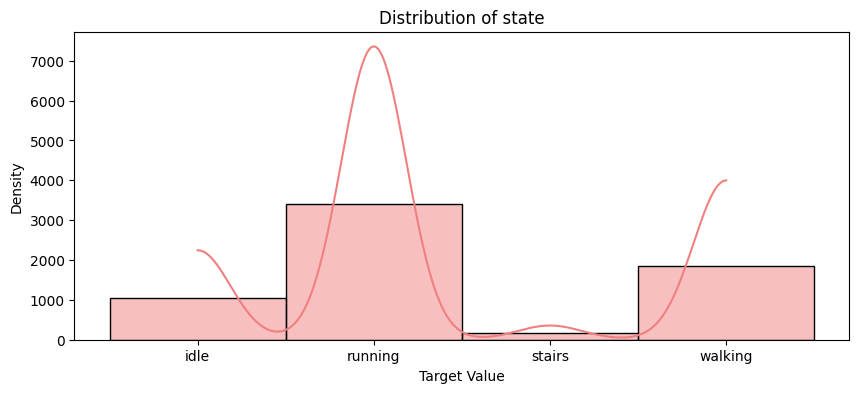

In [11]:
target_info(df, TARGET_NAME, transform=None)

In [12]:
df[TARGET_NAME] = df[TARGET_NAME].map({"running": 1, "walking": 2, "idle": 3, "stairs": 4})
df.head()

,mean_X,var_X,std_X,median_X,max_X,min_X,range_X,rms_X,skew_X,kurt_X,...,fft_magnitude_Y,fft_max_Y,fft_min_Y,fft_band_power_Z,fft_energy_Z,fft_dc_Z,fft_magnitude_Z,fft_max_Z,fft_min_Z,state
0,7.401487e-18,0.966667,0.983192,-0.271525,4.748541,-1.050064,5.798605,0.983192,3.839216,15.400041,...,4.828593,7.855532,1.332268e-15,14.506982,435.209455,2.530198e-13,4.281670,11.798137,2.530198e-13,3
1,1.665335e-17,0.966667,0.983192,-0.218708,4.883959,-1.001930,5.885889,0.983192,4.185307,17.579254,...,5.127667,11.223024,3.552714e-15,14.504438,435.133152,5.750955e-14,4.611639,8.711034,5.750955e-14,3
2,-6.476301e-17,0.966667,0.983192,-0.222546,4.980502,-0.793288,5.773790,0.983192,4.357639,19.061094,...,5.090128,9.082817,1.509903e-14,15.220474,456.614214,3.250733e-13,5.436441,7.141850,3.250733e-13,3
3,-4.996004e-17,0.966667,0.983192,-0.130111,4.124432,-1.808506,5.932938,0.983192,2.350880,8.623102,...,5.026615,9.212949,8.881784e-15,14.841498,445.244934,9.490186e-13,5.045575,8.265962,9.490186e-13,3
4,-1.147230e-16,0.966667,0.983192,-0.133789,4.072763,-1.793251,5.866014,0.983192,2.280946,8.083676,...,5.002792,9.300545,1.154632e-14,14.737735,442.132051,8.415491e-13,4.913642,8.903686,8.415491e-13,3


Train-test split to avoid data leakage during EDA

Важливо не перемішати датафрейм (data leakage) + account for class imbalance. We must shuffle train during cross-validation in batched gradient descent.
The correct approach: chronological split, no shuffle, no stratify. Handle imbalance via class_weight='balanced' in the model instead.

Train shape: (5169, 73)
Test shape: (1293, 73)

Unique target values:


,counts,%
state,,
1,2726,0.53
2,1480,0.29
3,831,0.16
4,132,0.03


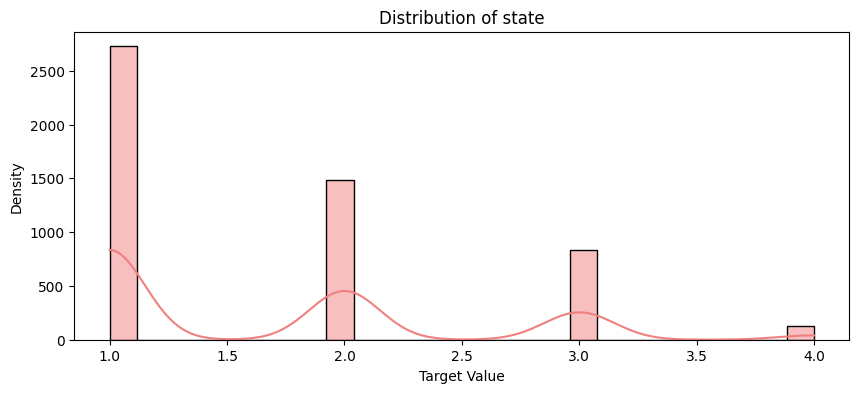

In [13]:
# train-test split (80/20)
from sklearn.model_selection import train_test_split

X = df.drop(columns=[TARGET_NAME])
y = df[TARGET_NAME]

# Параметр stratify=y зберігає ідентичний імбаланс класів у трейні і у тесті
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y, shuffle=True,
)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print()

target_info(df_train, TARGET_NAME)

In [14]:
# save the split
X_train.to_csv(Path('data') / '2 x_train_raw.csv')
y_train.to_csv(Path('data') / '2 y_train_raw.csv')
X_test.to_csv(Path('data') / '2 x_test_raw.csv')
y_test.to_csv(Path('data') / '2 y_test_raw.csv')

In [ ]:
# plot_features_against_target(df_train, df_train.columns, TARGET_NAME, bins={TARGET_NAME: 4}, imputed_masks=None, discrete_threshold=15)

the data is highly non-linear, even after the transformations. Linear models are going to be purely baseline, not the final prediction power.

В. Викиди (Outliers)Чи варто їх шукати? Так. У сирих даних акселерометра бувають апаратні глюки (наприклад, телефон різко стукнувся об стіл або датчик видав "спік" через затримку опитування ОС).У згенерованому датасеті такий глюк проявиться як аномально величезне значення у фічах max, range або energy.Використовуй правило IQR (міжквартильного розмаху), щоб підрахувати, скільки вікон мають ознаки, що виходять за межі $1.5 \times IQR$. Якщо таких рядків мало (менш як 1%), їх можна просто видалити з фінального датасету.


Outliers are present. Since we have quite a few features that are all skewed, we might use IQR - best for skewed data. Confirming via Cook's distance is skipped because linearity is out of the question. However, У задачах розпізнавання активності (Activity Recognition) або аналізу сенсорів, аномальний пік — це не просто "бруд", це може бути момент, коли людина впала, різко сіла або з силою кинула пристрій. Якщо ти повністю видалиш ці рядки через IQR, твоя модель взагалі розучиться розпізнавати екстремальні класи активностей.



In [14]:
winsor_limits, winsorized_masks = auto_iqr_winsorization_limits(df=df_train, target_name=TARGET_NAME, k=3.0)

mean_X    : 4.60% (133 upper and 105 lower) of mean_X would be capped (Limits: [-0.0000, 0.0000])
var_X     : 0.02% (1 upper and 0 lower) of var_X would be capped (Limits: [0.9667, 0.9667])
std_X     : 0.00% (0 upper and 0 lower) of std_X would be capped (Limits: [0.9832, 0.9832])
median_X  : 0.00% (0 upper and 0 lower) of median_X would be capped (Limits: [-0.5229, 0.4805])
max_X     : 0.00% (0 upper and 0 lower) of max_X would be capped (Limits: [0.3012, 5.2900])
min_X     : 0.00% (0 upper and 0 lower) of min_X would be capped (Limits: [-5.2844, -0.3456])
range_X   : 0.35% (18 upper and 0 lower) of range_X would be capped (Limits: [2.9916, 6.9972])
rms_X     : 0.00% (0 upper and 0 lower) of rms_X would be capped (Limits: [0.9832, 0.9832])
skew_X    : 0.08% (0 upper and 4 lower) of skew_X would be capped (Limits: [-4.8618, 5.1845])
kurt_X    : 4.86% (251 upper and 0 lower) of kurt_X would be capped (Limits: [-1.3291, 6.3344])
iqr_X     : 0.00% (0 upper and 0 lower) of iqr_X would be c

In [13]:
# plot_features_against_target(
#     data_frame=df_train,
#     features=X_train.columns,
#     target_name=TARGET_NAME,
#     bins={},
#     imputed_masks=winsorized_masks,
#     discrete_threshold=15,
# )

In [15]:
# 4. Застосовуємо кліпінг до обох датасетів на основі лімітів з train
for feat, (lower, upper) in winsor_limits.items():
    df_train[feat] = df_train[feat].clip(lower, upper)
    df_test[feat] = df_test[feat].clip(lower, upper)

Scaling

we've established the data is not linear and therefore we will either use non-linear SVM, which doesn't use GD, or trees. Neither of those need feature scaling. However, it's always good to have a simple model as a baseline. Given moderate multicollinearity (kappa=23.57), we are going to use L2 regularization that required standardization.

In [16]:
from sklearn.preprocessing import StandardScaler

# create and fit the scaler on TRAINING numerical data
scaler = StandardScaler().fit(X_train)

# transform the data
X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index) # <--- .transform() strips away the index column + it doesn't return column names!
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# 2. Safely combine features and target (Indices match perfectly)
df_train = pd.concat([X_train, df_train[[TARGET_NAME]]], axis=1)
df_test = pd.concat([X_test, df_test[[TARGET_NAME]]], axis=1)

display(df_train.head())
display(df_test.head())

,mean_X,var_X,std_X,median_X,max_X,min_X,range_X,rms_X,skew_X,kurt_X,...,fft_magnitude_Y,fft_max_Y,fft_min_Y,fft_band_power_Z,fft_energy_Z,fft_dc_Z,fft_magnitude_Z,fft_max_Z,fft_min_Z,state
1138,0.084912,0.000000e+00,1.110223e-16,-2.041297,0.329309,0.890952,-0.670730,1.110223e-16,0.937637,-0.213789,...,-3.610673,3.465758,-0.388567,-0.706925,-0.706925,-0.224922,0.144134,-0.481076,-0.224848,1
4684,-0.280099,0.000000e+00,1.110223e-16,1.237400,-1.771646,-1.504733,-0.094113,1.110223e-16,-1.750508,0.616241,...,0.012079,-0.067052,-0.422495,-0.763355,-0.763355,-0.224555,-0.584848,0.052437,-0.224481,2
5847,0.176165,-2.220446e-16,-1.110223e-16,-0.347877,0.368562,-0.032780,0.408938,-1.110223e-16,0.055646,-0.337243,...,-0.240295,-0.221121,0.357841,1.070781,1.070781,-0.222357,0.206098,-0.569590,-0.222283,2
1821,0.358671,2.220446e-16,1.110223e-16,-0.463165,0.981834,1.001858,-0.136935,1.110223e-16,0.710331,-0.106001,...,-0.308042,0.763133,-0.354640,1.045986,1.045986,-0.224555,1.125453,-1.343297,-0.224481,1
866,0.121414,-3.330669e-16,-3.330669e-16,0.714761,1.351425,0.227954,1.107483,-1.110223e-16,0.491223,0.286748,...,0.737778,-0.745636,-0.286784,0.297454,0.297454,-0.225288,-0.011659,-0.382692,-0.225214,3


,mean_X,var_X,std_X,median_X,max_X,min_X,range_X,rms_X,skew_X,kurt_X,...,fft_magnitude_Y,fft_max_Y,fft_min_Y,fft_band_power_Z,fft_energy_Z,fft_dc_Z,fft_magnitude_Z,fft_max_Z,fft_min_Z,state
2306,0.039286,-3.330669e-16,-3.330669e-16,0.333060,-0.460895,0.135283,-0.617550,-3.330669e-16,-0.222131,-0.693115,...,0.383740,-1.001243,-0.388567,0.083679,0.083679,-0.224555,-1.097285,-0.503615,-0.224481,1
380,-3.528699,0.000000e+00,1.110223e-16,1.227070,-0.586968,-0.043496,-0.543518,-1.110223e-16,-0.385736,-0.549754,...,-0.088221,-0.185009,-0.422495,2.169990,2.169990,2.407069,0.266971,0.109483,2.407137,3
3734,-0.015466,0.000000e+00,1.110223e-16,1.125629,-0.680363,-1.259937,0.731818,1.110223e-16,-1.052219,-0.062978,...,-0.269768,0.261530,-0.380085,-0.206802,-0.206802,-0.222357,-1.000079,0.942648,-0.222283,1
6106,0.002785,-2.220446e-16,-1.110223e-16,1.517116,-0.350204,-0.563596,0.281062,-1.110223e-16,-0.372755,-0.451171,...,-0.029756,1.291589,0.256058,0.024785,0.024785,-0.223822,0.102044,-0.054713,-0.223748,2
3294,0.386047,0.000000e+00,1.110223e-16,-1.056392,0.534192,0.902318,-0.476716,1.110223e-16,0.615872,-0.370725,...,-1.445660,1.387327,-0.119267,-0.213112,-0.213112,-0.221624,-1.903528,2.201682,-0.221550,1


In [17]:
df_train_copy = df_train.copy()
df_test_copy = df_test.copy()

In [22]:
df_train = df_train_copy.copy()
df_test = df_test_copy.copy()

In [18]:
correlations = render_correlations(df_train, is_to_plot=False, threshold=0.9)
correlations

,Feature 1,Feature 2,Correlation
0,fft_band_power_X,fft_energy_X,1.000000
1,fft_dc_X,fft_min_X,1.000000
2,fft_band_power_Y,fft_energy_Y,1.000000
3,fft_band_power_Z,fft_energy_Z,1.000000
4,fft_dc_Z,fft_min_Z,0.999986
5,fft_dc_Y,fft_min_Y,0.999638
6,var_Z,power_Z,0.916163
7,std_Z,rms_Z,0.908554
8,kurt_X,entropy_X,-0.900047


In [19]:
correlations['Feature 1'].unique()

array(['fft_band_power_X', 'fft_dc_X', 'fft_band_power_Y',
       'fft_band_power_Z', 'fft_dc_Z', 'fft_dc_Y', 'var_Z', 'std_Z',
       'kurt_X'], dtype=object)

In [20]:
df_train = df_train.drop(columns=correlations['Feature 1'].unique())
df_test = df_test.drop(columns=correlations['Feature 1'].unique())
correlations = render_correlations(df_train, is_to_plot=False, threshold=0.9)
correlations

No entries to plot for a threshold of 0.9


,Feature 1,Feature 2,Correlation


In [21]:
detect_perfect_multicollinearity_via_rank(df_train, TARGET_NAME)

Matrix rank: 60 / 64 features
Perfect multicollinearity detected — 4 exact dependencies.


60

In [ ]:
from scipy.linalg import qr

def find_redundant_columns_qr(df: pd.DataFrame, target_name: str, tol: float = 1e-10) -> list:
    """
    QR decomposition with column pivoting to identify exactly which columns are linear combinations of others. O(n_features^2 * n_samples) — instant even for 60+ features.

    Works on the standardized matrix so that scale differences don't distort
    the numerical rank estimate (same reason VIF needs scaling).

    """
    X = df.drop(columns=[target_name])
    cols = X.columns.tolist()

    # Standardize — raw feature scales differ by orders of magnitude which
    # causes the SVD tolerance to misclassify near-zero singular values
    X_std = (X - X.mean()) / X.std()

    _, R, P = qr(X_std.values, pivoting=True)

    # Diagonal of R: near-zero entries signal linearly dependent columns
    diag = np.abs(np.diag(R))
    rank = int(np.sum(diag > tol * diag[0]))
    redundant_indices = P[rank:]  # column indices pivoted to the back = redundant

    redundant_cols = [cols[i] for i in redundant_indices]

    print(f"Rank: {rank} / {len(cols)}")
    print(f"Redundant columns ({len(redundant_cols)}): {redundant_cols}")
    return redundant_cols

Rank: 60 / 64
Redundant columns (4): ['sma', 'max_Y', 'range_Z', 'min_X']


['sma', 'max_Y', 'range_Z', 'min_X']

In [23]:
to_drop_qr = find_redundant_columns_qr(df_train, TARGET_NAME)
to_drop_qr

Rank: 60 / 64
Redundant columns (4): ['sma', 'max_Y', 'range_Z', 'min_X']


['sma', 'max_Y', 'range_Z', 'min_X']

In [24]:
df_train = df_train.drop(columns=to_drop_qr)
df_test  = df_test.drop(columns=to_drop_qr)

In [25]:
detect_perfect_multicollinearity_via_rank(df_train, TARGET_NAME)

Matrix rank: 60 / 60 features


60

In [26]:
perform_advanced_vif_analysis(df_train, TARGET_NAME, to_scale=False)

,feature,VIF,theta,matrix_kappa
0,max_X,22.754209,0.066354,20.69818
1,skew_Z,21.356468,0.064284,20.69818
2,skew_X,20.855553,0.063526,20.69818
3,mad_Z,20.168592,0.062471,20.69818
4,min_Y,13.666326,0.051424,20.69818
5,mad_X,12.817497,0.049801,20.69818
6,range_X,10.523070,0.045124,20.69818
7,min_Z,10.332015,0.044713,20.69818
8,max_Z,10.330694,0.044710,20.69818
9,skew_Y,10.280952,0.044602,20.69818


VIF максимуми ($37.5$, $30.3$, $23.6$): Вони чітко локалізують, чому $\kappa$ зсунувся в жовту зону. Подивись на імена фіч: mad_Z (Mean Absolute Deviation по осі Z), range_Z (діапазон по Z), sma (Signal Magnitude Area), min_Z, max_X, median_Z. Що тут відбувається? Вісь $Z$ сильно перевантажена спорідненими математичними агрегатами, які частково дублюють один одного.

$\kappa = 23.57$ (Жовтий прапорець): Це каже, що простір даних починає витягуватися в еліпсоїд. Співвідношення найдовшої осі до найкоротшої становить приблизно $23.5$. Матриця ще не руйнується, але вона вже не є ідеально круглою сферою. Якщо ти плануєш будувати Логістичну регресію (для класифікації активностей) або SVM з лінійним ядром, то $\kappa = 23.57$ вимагає від тебе обов'язкового увімкнення Ridge-регуляризації (L2). Тобі не можна використовувати "чистий" лінійний класифікатор без штрафу ваг, інакше модель почне надто сильно фокусуватися на осі $Z$.

Констатувати, що за критерієм $\theta \le 0.20$ модель є стабільною завдяки об'єму вибірки. Об'єм твоїх даних ($n = 6000$ або близько того) настільки великий, що він повністю поглинає і нейтралізує цей локальний VIF. Бутстреп тут не потрібен, бо математично доведено: твої стандартні помилки стиснуті великою вибіркою, і коефіцієнти моделі будуть стабільними від перезапуску до перезапуску.

In [27]:
psi_scores = calculate_feature_psi(
    x_sample=df_train,
    x_evaluation=df_test,
    target_name=TARGET_NAME,
    num_bins=10,
)

print("\n--- Population Stability Index (PSI) Scores ---")
print(psi_scores)


--- Population Stability Index (PSI) Scores ---
iqr_X              0.022817
skew_X             0.022675
max_X              0.020908
kurt_Z             0.017235
entropy_X          0.016000
fft_max_X          0.015721
fft_magnitude_Z    0.015435
fft_magnitude_X    0.013833
median_Y           0.012969
skew_Y             0.012950
mad_X              0.012775
skew_Z             0.012624
range_Y            0.011891
median_X           0.011837
entropy_Y          0.011200
mad_Z              0.010901
max_Z              0.010770
idx_max_Z          0.010733
fft_min_Y          0.010298
corr_XZ            0.010185
corr_YZ            0.009633
mean_Z             0.008987
idx_max_Y          0.008583
fft_max_Z          0.008530
min_Z              0.008505
kurt_Y             0.008130
iqr_Z              0.007348
range_X            0.007289
idx_min_X          0.007136
fft_min_X          0.007078
corr_XY            0.007004
entropy_Z          0.006517
idx_min_Z          0.006441
median_Z           0.006162

All features are below the 
 threshold.
The conclusion: The assumption holds, we may state that training data perfectly represents the test set.

в інженерії сенсорів (особливо акселерометрів) temporal dependency (часова залежність) — це головна архітектурна особливість даних, яку не можна ігнорувати.  Оскільки ти розраховуєш фічі по ковзних вікнах (тайм-серіях), вікно у момент часу $t$ неминуче копіює 90% інформації з вікна у момент $t-1$.

In [29]:
import inspect
import warnings
from functools import wraps
from itertools import combinations
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from numpy.linalg import matrix_rank
from scipy import stats
from statsmodels.api import add_constant
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan, het_white
from statsmodels.tsa.stattools import adfuller, kpss


def ensure_target_not_included(func):
    """A Decorator that dynamically drops the target variable from ANY pandas DataFrame passed to the function."""

    @wraps(func)  # to preserve original function's metadata
    def wrapper(*args, **kwargs):  # accept required params and pass all the others
        # Bind the provided arguments to the function's signature
        sig = inspect.signature(func)
        bound_args = sig.bind(*args, **kwargs)
        bound_args.apply_defaults()

        # The function must have a target_name argument for us to know what to drop
        target_name = bound_args.arguments.get("target_name")
        if not target_name:
            msg = f"Function '{func.__name__}' must accept a 'target_name' argument to use this decorator."
            raise ValueError(msg)

        # Scan all arguments. If it's a DataFrame, drop the target.
        for name, value in bound_args.arguments.items():
            if isinstance(value, pd.DataFrame) and target_name in value.columns:
                bound_args.arguments[name] = value.drop(columns=[target_name])

        # Execute the original function with the cleaned arguments
        return func(*bound_args.args, **bound_args.kwargs)

    return wrapper


def ensure_categoricals_encoded(func):
    """A Decorator that ensures all categoricals are handled in ALL DataFrames passed to the function."""

    @wraps(func)
    def wrapper(*args, **kwargs):
        # Bind the provided arguments to the function's signature
        sig = inspect.signature(func)
        bound_args = sig.bind(*args, **kwargs)
        bound_args.apply_defaults()

        # Scan all arguments for DataFrames and validate their dtypes
        for name, value in bound_args.arguments.items():
            if isinstance(value, pd.DataFrame):
                has_objects = (value.dtypes == "object").any()
                has_categories = (value.dtypes == "category").any()

                if has_objects or has_categories:
                    msg = f"DataFrame argument '{name}' contains unencoded categorical values. Aborted."
                    raise ValueError(msg)

        # Execute if all DataFrames pass the check
        return func(*bound_args.args, **bound_args.kwargs)

    return wrapper


def ensure_no_nulls(func):
    """A Decorator that ensures all nulls are imputed in ALL DataFrames passed to the function."""

    @wraps(func)
    def wrapper(*args, **kwargs):
        # Bind the provided arguments to the function's signature
        sig = inspect.signature(func)
        bound_args = sig.bind(*args, **kwargs)
        bound_args.apply_defaults()

        # Scan all arguments for DataFrames and check for missing values
        for name, value in bound_args.arguments.items():
            if isinstance(value, pd.DataFrame) and value.isna().any().any():
                msg = f"DataFrame argument '{name}' has missing values. Aborted."
                raise ValueError(msg)

        # Execute if all DataFrames pass the check
        return func(*bound_args.args, **bound_args.kwargs)

    return wrapper


def ensure_constant_included(func):
    """A Decorator that ensures the column of ones is in @."""

    @wraps(func)
    def wrapper(features: np.ndarray[np.float64], *args, **kwargs):
        if not np.any(np.all(features == 1.0, axis=0)):
            raise ValueError("x_features_with_added_constant must contain a column of ones.")
        return func(features, *args, **kwargs)

    return wrapper


def ensure_series_has_no_nulls(func):
    """A Decorator that ensures a pandas Series argument has no missing values."""

    @wraps(func)
    def wrapper(*args, **kwargs):
        sig = inspect.signature(func)
        bound_args = sig.bind(*args, **kwargs)
        bound_args.apply_defaults()

        for name, value in bound_args.arguments.items():
            if isinstance(value, pd.Series) and value.isna().any():
                msg = f"Series argument '{name}' has missing values. Aborted."
                raise ValueError(msg)

        return func(*bound_args.args, **bound_args.kwargs)

    return wrapper

@ensure_no_nulls
@ensure_categoricals_encoded
def screen_autocorrelation_stage1(
    df: pd.DataFrame,
    target_name: str,
    max_lag: int = 40,
    alpha: float = 0.05,
    mode: str = "regression",  # "regression" or "classification"
) -> pd.DataFrame:
    """
    Stage 1: screen raw series for temporal autocorrelation BEFORE fitting any model.

    Goal: identify which features (and target, for regression) have temporal memory
    worth exploiting via lag features.

    Regression: checks all columns including target as a single chronological series.
    Classification: checks each feature WITHIN each class separately to avoid
    confusing genuine within-state persistence with class-transition jumps.
    The target (discrete labels) is excluded — Ljung-Box on categorical integers
    would just detect that classes persist over consecutive rows, which is trivially
    known and not actionable.

    Args:
        df: Training DataFrame sorted chronologically.
        target_name: Target column name.
        max_lag: Joint test covers lags 1 through max_lag.
        alpha: Flagging threshold.
        mode: "regression" or "classification".

    Returns:
        DataFrame of results sorted by p-value ascending (most suspicious first).

    """
    records = []

    if mode == "regression":
        cols_to_check = df.columns  # target included — it's continuous and meaningful to check
        for col in cols_to_check:
            series = df[col].to_numpy()
            lb_test = acorr_ljungbox(series, lags=[max_lag], return_df=True)
            records.append({
                "Feature": col,
                "Is Target": col == target_name,
                f"LB_Stat (Lag {max_lag})": lb_test.loc[max_lag, "lb_stat"],
                "p-value": lb_test.loc[max_lag, "lb_pvalue"],
                "Flagged": lb_test.loc[max_lag, "lb_pvalue"] < alpha,
            })

    elif mode == "classification":
        feature_cols = [c for c in df.columns if c != target_name]
        for class_label in df[target_name].unique():
            class_df = df[df[target_name] == class_label]
            for col in feature_cols:
                series = class_df[col].to_numpy()
                if len(series) <= max_lag:
                    # not enough rows in this class to test at this lag depth
                    continue
                lb_test = acorr_ljungbox(series, lags=[max_lag], return_df=True)
                records.append({
                    "Class": class_label,
                    "Feature": col,
                    f"LB_Stat (Lag {max_lag})": lb_test.loc[max_lag, "lb_stat"],
                    "p-value": lb_test.loc[max_lag, "lb_pvalue"],
                    "Flagged": lb_test.loc[max_lag, "lb_pvalue"] < alpha,
                })

    return pd.DataFrame(records).sort_values("p-value").reset_index(drop=True)

In [30]:
sreenings = screen_autocorrelation_stage1(df_train, TARGET_NAME, mode="classification")
sreenings

,Class,Feature,LB_Stat (Lag 40),p-value,Flagged
0,2,rms_X,64.736371,0.007932,True
1,4,min_Z,63.238860,0.011038,True
2,4,skew_Z,60.391876,0.020183,True
3,3,fft_magnitude_X,59.853575,0.022537,True
4,1,range_X,57.596235,0.035299,True
...,...,...,...,...,...
235,4,energy_X,23.922088,0.979342,False
236,4,range_Y,22.484065,0.988492,False
237,3,corr_XY,22.466575,0.988579,False
238,4,idx_min_X,21.866235,0.991259,False


In [31]:
sreenings[sreenings['Flagged']]

,Class,Feature,LB_Stat (Lag 40),p-value,Flagged
0,2,rms_X,64.736371,0.007932,True
1,4,min_Z,63.238860,0.011038,True
2,4,skew_Z,60.391876,0.020183,True
3,3,fft_magnitude_X,59.853575,0.022537,True
4,1,range_X,57.596235,0.035299,True
5,2,fft_min_Z,56.516436,0.043395,True
6,2,corr_XY,56.492643,0.043590,True
7,2,fft_magnitude_X,56.267771,0.045473,True


Since our row represents ~2 sec of data, window size=30

In [34]:
@ensure_series_has_no_nulls
def check_stationarity(
    series: pd.Series,
    target_name: str = None,
    alpha: float = 0.05,
    regression: str = "c",
    window: int = None,
    plot: bool = True,
    verbose: bool = True,
):
    """
    Combined ADF + KPSS stationarity check with a 4-quadrant verdict.

    - ADF  H0: series HAS a unit root (non-stationary). Reject (p < alpha) -> stationary.
    - KPSS H0: series IS stationary.                     Reject (p < alpha) -> non-stationary.

    Both are still p-value-based tests and share the general large-N caveat (statistically
    significant != practically meaningful with enough rows). Treat the verdict as a fast
    screen, not a final answer -- when ADF and KPSS disagree, or even when they agree,
    trust the rolling mean/std plot (plot=True) over either p-value; it's the diagnostic
    that doesn't depend on sample size.

    Args:
        series (pd.Series): Time series to test (e.g. the target, hourly-indexed).
        target_name (str): Optional, used only for print/plot labeling.
        alpha (float, default=0.05): Significance level for both tests.
        regression (str, default='c'): 'c' (level) or 'ct' (level+trend). Passed to ADF
            directly ('ctt'/'n' also valid for ADF only); mapped to KPSS's 'c'/'ct'.
        window (int): Rolling window for the mean/std plot. Defaults to a small fraction
            of series length -- override with something tied to your data's natural cycle
            (e.g. 24 for hourly data with a daily cycle).
        plot (bool, default=True): Draw raw series + rolling mean/std.
        verbose (bool, default=True): Print results to console.

    Returns:
        dict: {'adf': {...}, 'kpss': {...}, 'verdict': str, 'agreement': bool}

    """
    s = series.dropna().astype(float)
    n = len(s)
    if n < 10:
        raise ValueError("Series too short for stationarity testing (need more observations).")

    # --- ADF ---
    adf_stat, adf_pvalue, adf_usedlag, adf_nobs, adf_crit = adfuller(s.values, regression=regression, autolag="AIC")[:5]
    adf_is_stationary = adf_pvalue < alpha

    # --- KPSS --- (only supports 'c' / 'ct'; map anything else to 'c')
    kpss_regression = "ct" if regression == "ct" else "c"
    with warnings.catch_warnings():
        # statsmodels caps KPSS p-values to its lookup-table range (e.g. "p-value is
        # smaller than the smallest p-value tested") -- silenced here for readability,
        # but the printed p-value can be pinned at 0.01 or 0.10 rather than exact.
        warnings.simplefilter("ignore")
        kpss_stat, kpss_pvalue, kpss_usedlag, kpss_crit = kpss(s.values, regression=kpss_regression, nlags="auto")
    kpss_is_stationary = kpss_pvalue >= alpha  # opposite direction from ADF

    # --- Combined verdict ---
    if adf_is_stationary and kpss_is_stationary:
        verdict, agreement = "stationary", True
    elif not adf_is_stationary and not kpss_is_stationary:
        verdict, agreement = "non-stationary", True
    else:
        verdict, agreement = "conflicting", False

    if verbose:
        label = f" [{target_name}]" if target_name else ""
        print(f"--- Stationarity check{label} (n={n}) ---")
        print(
            f"ADF  stat={adf_stat:.4f}  p={adf_pvalue:.4f}  used_lag={adf_usedlag}  "
            f"-> {'stationary' if adf_is_stationary else 'non-stationary'}",
        )
        print(
            f"KPSS stat={kpss_stat:.4f}  p={kpss_pvalue:.4f}  used_lag={kpss_usedlag}  "
            f"-> {'stationary' if kpss_is_stationary else 'non-stationary'}",
        )
        print(f"=> Verdict: {verdict.upper()}" + ("" if agreement else " -- tests disagree, check the plot before deciding."))

    if plot:
        w = window or min(max(n // 10, 2), 30)
        roll_mean, roll_std = s.rolling(w).mean(), s.rolling(w).std()

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(s.values, alpha=0.3, label="raw")
        ax.plot(roll_mean.values, label=f"rolling mean (w={w})")
        ax.plot(roll_std.values, label=f"rolling std (w={w})")
        ax.set_title(f"Stationarity{(' — ' + target_name) if target_name else ''} — verdict: {verdict}")
        ax.legend()
        plt.show()

    return {
        "adf": {
            "stat": adf_stat,
            "p_value": adf_pvalue,
            "used_lag": adf_usedlag,
            "nobs": adf_nobs,
            "critical_values": adf_crit,
            "is_stationary": adf_is_stationary,
        },
        "kpss": {
            "stat": kpss_stat,
            "p_value": kpss_pvalue,
            "used_lag": kpss_usedlag,
            "critical_values": kpss_crit,
            "is_stationary": kpss_is_stationary,
        },
        "verdict": verdict,
        "agreement": agreement,
    }

--- Stationarity check [state] (n=5169) ---
ADF  stat=0.0136  p=0.9596  used_lag=0  -> non-stationary
KPSS stat=0.1860  p=0.1000  used_lag=11  -> stationary
=> Verdict: CONFLICTING -- tests disagree, check the plot before deciding.


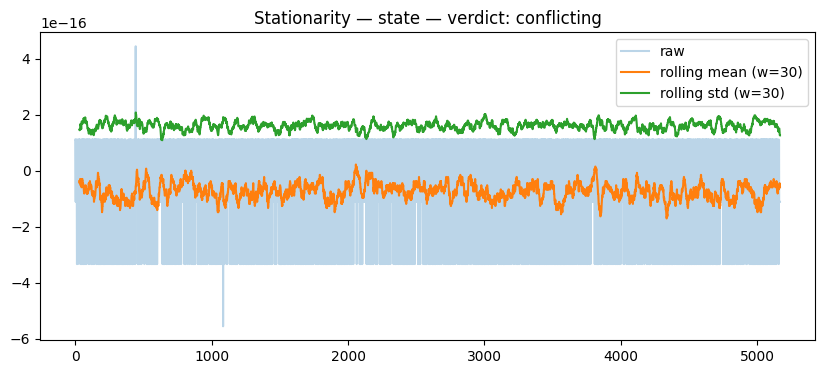

--- Stationarity check [state] (n=5169) ---
ADF  stat=-72.7901  p=0.0000  used_lag=0  -> stationary
KPSS stat=0.2996  p=0.1000  used_lag=13  -> stationary
=> Verdict: STATIONARY


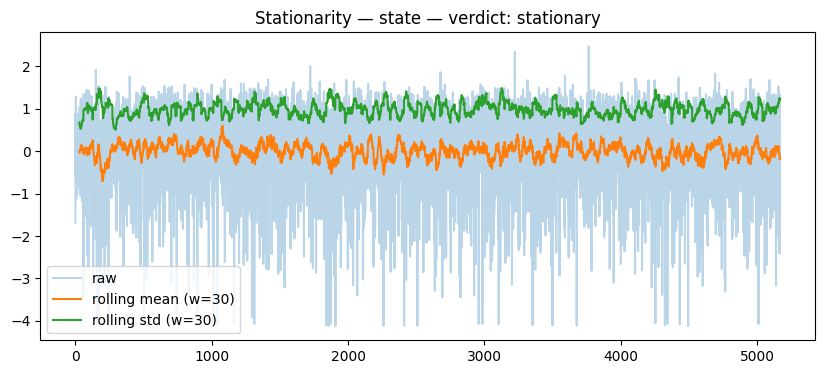

--- Stationarity check [state] (n=5169) ---
ADF  stat=-73.8685  p=0.0000  used_lag=0  -> stationary
KPSS stat=0.1085  p=0.1000  used_lag=5  -> stationary
=> Verdict: STATIONARY


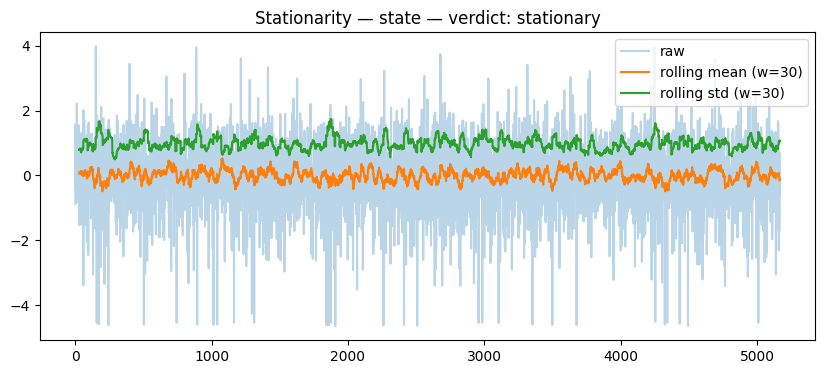

--- Stationarity check [state] (n=5169) ---
ADF  stat=-71.7342  p=0.0000  used_lag=0  -> stationary
KPSS stat=0.0656  p=0.1000  used_lag=8  -> stationary
=> Verdict: STATIONARY


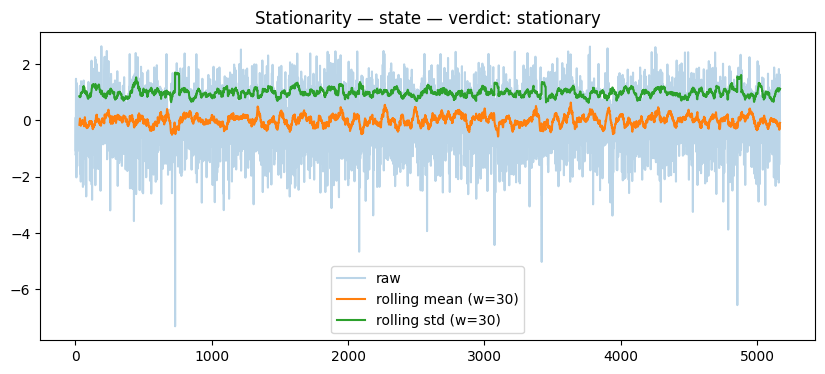

--- Stationarity check [state] (n=5169) ---
ADF  stat=-50.5213  p=0.0000  used_lag=1  -> stationary
KPSS stat=0.0656  p=0.1000  used_lag=9  -> stationary
=> Verdict: STATIONARY


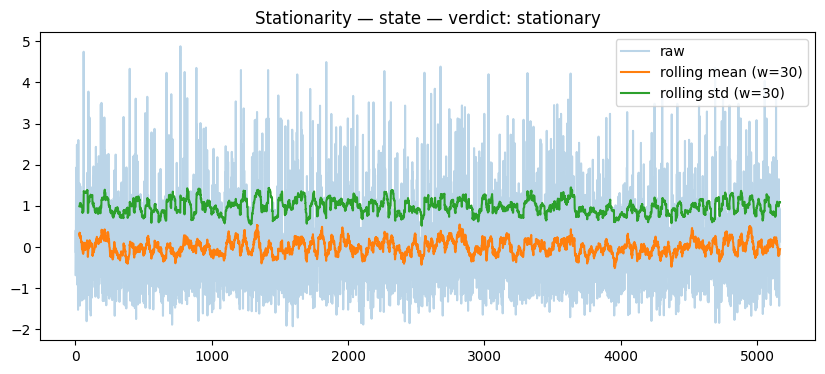

--- Stationarity check [state] (n=5169) ---
ADF  stat=-72.2328  p=0.0000  used_lag=0  -> stationary
KPSS stat=0.1199  p=0.1000  used_lag=12  -> stationary
=> Verdict: STATIONARY


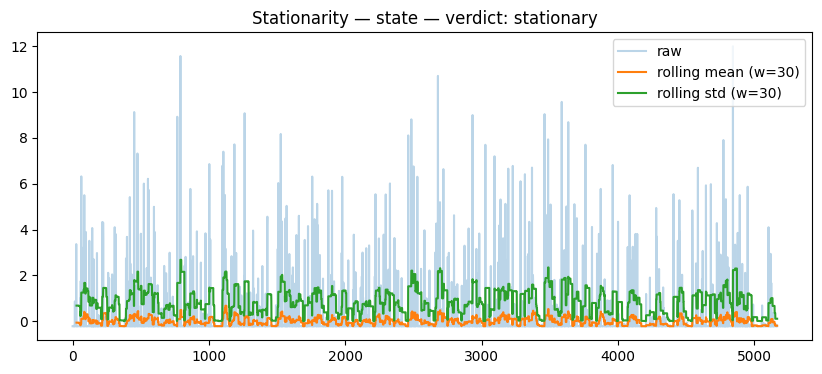

--- Stationarity check [state] (n=5169) ---
ADF  stat=-72.2679  p=0.0000  used_lag=0  -> stationary
KPSS stat=0.0587  p=0.1000  used_lag=4  -> stationary
=> Verdict: STATIONARY


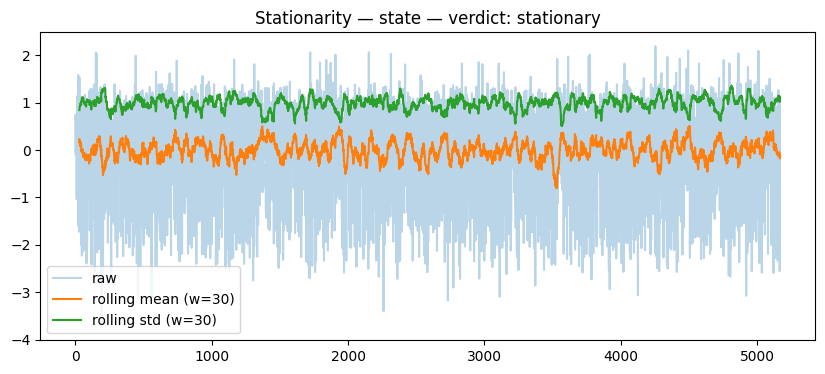

--- Stationarity check [state] (n=5169) ---
ADF  stat=-71.7342  p=0.0000  used_lag=0  -> stationary
KPSS stat=0.0656  p=0.1000  used_lag=8  -> stationary
=> Verdict: STATIONARY


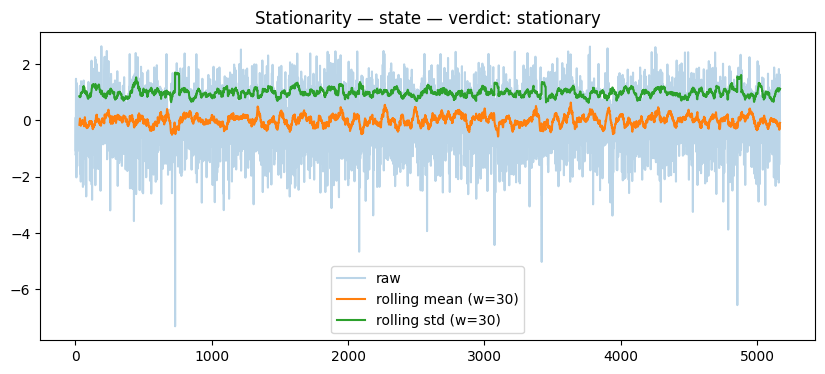

In [35]:
for feat in sreenings.loc[sreenings['Flagged'], 'Feature']:
    check_stationarity(df_train[feat], TARGET_NAME, 0.05, "c", 30, True, True)

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor


@ensure_categoricals_encoded
@ensure_no_nulls
def run_acorr_ljungbox_for_classification_residuals(df: pd.DataFrame, target_name: str, class_labels: list, max_lag: int = 40) -> pd.DataFrame:
    """The df - train df sorted chronologically."""
    df_copy = df.copy()
    X = df_copy.drop(columns=[target_name])
    # Remove the intercept if it exists in your features
    if "const" in X.columns:
        X = X.drop(columns=["const"])
    # Initialize a list to collect results for the final DataFrame
    records = []
    # Iterate over every unique class to perform OvA (One-vs-All) residual analysis
    for class_label in class_labels:
        # Convert multi-class labels into binary outcomes (1 for the target class, 0 for everything else)
        y_binary = (df_copy[target_name] == class_label).astype(int)
        clf = ExtraTreesClassifier(n_estimators=200, random_state=42)
        clf.fit(X, y_binary)
        p_hat = clf.predict_proba(X)[:, 1]
        resid = y_binary.to_numpy() - p_hat
        lb_test = acorr_ljungbox(resid, lags=[max_lag], return_df=True)
        # Extract test metrics
        lb_stat = lb_test.loc[max_lag, "lb_stat"]
        p_value = lb_test.loc[max_lag, "lb_pvalue"]
        # Append data as a dictionary
        records.append(
            {"Class": class_label, f"LB_Stat (Lag {max_lag})": lb_stat, "p-value": p_value},
        )
    return pd.DataFrame(records)

@ensure_no_nulls
@ensure_categoricals_encoded
def run_acorr_ljungbox_for_regression_residuals(
    df: pd.DataFrame,
    target_name: str,
    max_lag: int = 40,
    alpha: float = 0.05,
) -> pd.DataFrame:
    """
    Stage 2: fit a flexible model and check whether its residuals still carry temporal structure the model failed to absorb.

    Uses ExtraTreesRegressor as the baseline — strong and nonlinear, so any
    remaining autocorrelation in residuals is genuinely missing temporal signal,
    not a symptom of a weak model.

    Swap in sm.OLS if your goal is inference rather than predictive power
    (in that case you're validating OLS's own assumptions, not a generic baseline).

    Args:
        df: Training DataFrame sorted chronologically.
        target_name: Target column name.
        max_lag: Joint test covers lags 1 through max_lag.
        alpha: Flagging threshold.

    Returns:
        Single-row DataFrame with the Ljung-Box result and a Flagged column.

    """
    X = df.drop(columns=[target_name])
    y = df[target_name]

    model = ExtraTreesRegressor(n_estimators=200, random_state=42)
    model.fit(X, y)
    resid = y.to_numpy() - model.predict(X)

    lb_test = acorr_ljungbox(resid, lags=[max_lag], return_df=True)
    lb_stat = lb_test.loc[max_lag, "lb_stat"]
    p_value = lb_test.loc[max_lag, "lb_pvalue"]

    return pd.DataFrame([{
        f"LB_Stat (Lag {max_lag})": lb_stat,
        "p-value": p_value,
        "Flagged": p_value < alpha,
    }])

## Training

In [ ]:
from joblib import parallel_backend
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

Prepare the data

In [ ]:
X_train, y_train = df_train.drop(columns=[TARGET_NAME]), df_train[TARGET_NAME]
X_test, y_test = df_test.drop(columns=[TARGET_NAME]), df_test[TARGET_NAME]

The Tuning Philosophy: SVMs are mathematically rigid. Their performance hinges heavily on a small set of interacting continuous parameters—primarily the regularization parameter ($C$) and the kernel coefficient ($\gamma$). Because the parameter space is relatively small but highly sensitive to specific combinations, we use GridSearchCV to exhaustively test every specified combination.

In [ ]:
# 1. Define your pipeline and grid
svm_pipeline = Pipeline([
    ('svm', SVC(class_weight='balanced', random_state=RANDOM_SEED)),
])

svm_param_grid = [
    {'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 2, 3]},
    {'svm__kernel': ['rbf'], 'svm__C': [0.1, 1, 2, 3], 'svm__gamma': ['scale', 'auto', 0.1, 0.5, 1]},
    {'svm__kernel': ['poly'], 'svm__C': [0.1, 1, 2, 3], 'svm__degree': [2, 3]},
]

tscv = TimeSeriesSplit(n_splits=5)

# 2. Setup grid search with verbose=3
svm_grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=3,
)

# 3. Fit the model using threading backend so prints show up live
print("Starting grid search...")
with parallel_backend('threading'):
    svm_grid_search.fit(X_train, y_train)

# 4. Print the best training results
print(f"\nBest estimator: {svm_grid_search.best_estimator_}\n")
print(f"Best SVM Parameters: {svm_grid_search.best_params_}")
print(f"Best SVM CV Score: {svm_grid_search.best_score_:.4f}\n")

# 5. Predict on your test dataset
print("Evaluating on test data...")
y_pred = svm_grid_search.predict(X_test)

print("\n=== TEST SET CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

Evaluating on test data...

=== TEST SET CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       682
           2       0.99      0.97      0.98       370
           3       1.00      1.00      1.00       208
           4       0.74      0.88      0.81        33

    accuracy                           0.99      1293
   macro avg       0.93      0.96      0.95      1293
weighted avg       0.99      0.99      0.99      1293

=== TEST SET CONFUSION MATRIX ===
[[682   0   0   0]
 [  1 359   0  10]
 [  0   0 208   0]
 [  0   4   0  29]]


The Tuning Philosophy: Random Forests have a massive hyperparameter space (n_estimators, max_depth, min_samples_split, max_features, etc.). Running an exhaustive grid search on a forest is computationally crippling and mathematically unnecessary. Research shows that testing a random sample of parameter combinations (RandomizedSearchCV) yields near-optimal results in a fraction of the time, because only a few hyperparameters truly dictate the model's success.

In [73]:
rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(class_weight="balanced", random_state=RANDOM_SEED)),
])

rf_param_dist = {
    'rf__n_estimators': np.arange(100, 1001, 100),
    'rf__max_depth': [None, 10, 20, 30, 40, 50],
    'rf__min_samples_split': np.arange(2, 21, 2),
    'rf__min_samples_leaf': np.arange(1, 11, 2),
    'rf__max_features': ['sqrt', 'log2', None],
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=30,          # 30 random combinations to run (out of 10 * 6 * 10 * 5 * 3 = 2,700 options)
    cv=TimeSeriesSplit(n_splits=5),
    scoring='f1_macro',
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=3,
)

print("Starting randomized grid search...")
with parallel_backend('threading'):
    rf_random_search.fit(X_train, y_train)

print(f"Best estimator: {rf_random_search.best_estimator_}\n")
print(f"Best RF Parameters: {rf_random_search.best_params_}")
print(f"Best RF CV Score: {rf_random_search.best_score_:.4f}\n")

print("Evaluating on test data...")
y_pred = rf_random_search.predict(X_test)

print("\n=== TEST SET CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

Starting randomized grid search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END rf__max_depth=None, rf__max_features=log2, rf__min_samples_leaf=7, rf__min_samples_split=14, rf__n_estimators=100;, score=0.946 total time=   1.8s
[CV 1/5] END rf__max_depth=30, rf__max_features=log2, rf__min_samples_leaf=7, rf__min_samples_split=20, rf__n_estimators=100;, score=0.946 total time=   1.8s
[CV 2/5] END rf__max_depth=None, rf__max_features=log2, rf__min_samples_leaf=7, rf__min_samples_split=14, rf__n_estimators=100;, score=0.977 total time=   2.2s
[CV 2/5] END rf__max_depth=30, rf__max_features=log2, rf__min_samples_leaf=7, rf__min_samples_split=20, rf__n_estimators=100;, score=0.969 total time=   2.3s
[CV 1/5] END rf__max_depth=40, rf__max_features=None, rf__min_samples_leaf=5, rf__min_samples_split=16, rf__n_estimators=100;, score=0.915 total time=   2.5s
[CV 3/5] END rf__max_depth=None, rf__max_features=log2, rf__min_samples_leaf=7, rf__min_samples_split=14, rf_

1. Is it correct to deal with correlation on df (therefore with test data included) and not on df_train abd\\nd then applying changes on train?
2. Is it correct that all features >= 0.9 are indeed bound to be removed (knowing that multicollinearity is an issue for the model)? I mean is the threshold high enough for them to be predetermined for removal?
3. 